## CLUSTERING AVEC L ALGORITHME CLIQUE

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pyclustering.cluster.clique import clique, clique_visualizer
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

In [11]:
# Création de données avec 3 clusters
data, true_labels = make_blobs(n_samples=300, centers=3, cluster_std=0.6, random_state=42) #make_blobs() est une fonction qui génère des données artificielles regroupées en clusters

# Ajout de quelques points de bruit
noise = np.random.uniform(low=-10, high=10, size=(20, 2))
data = np.vstack([data, noise])

print(f"Forme des données : {data.shape}")
print("Aperçu des 5 premiers points :")
print(data[:5])

Forme des données : (320, 2)
Aperçu des 5 premiers points :
[[-7.15524373 -7.39001621]
 [-7.39587521 -7.11084292]
 [-2.01567068  8.28177994]
 [ 4.50927011  2.6324358 ]
 [-8.10250191 -7.48496138]]


Clusters trouvés : 3
Bruit : 0 points


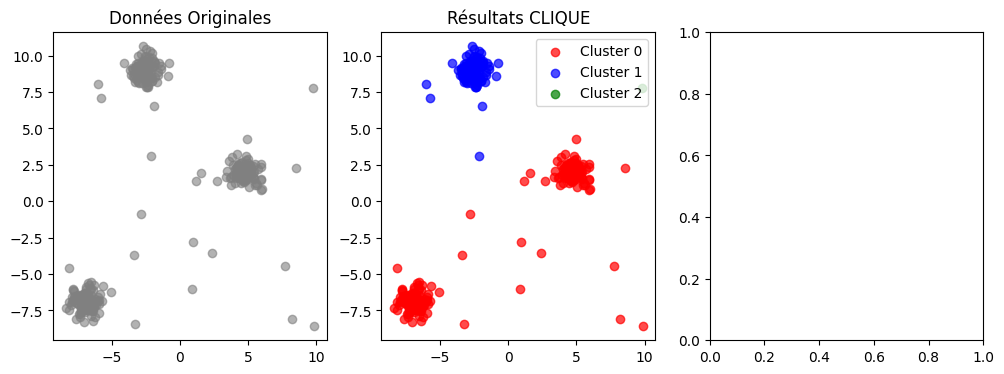

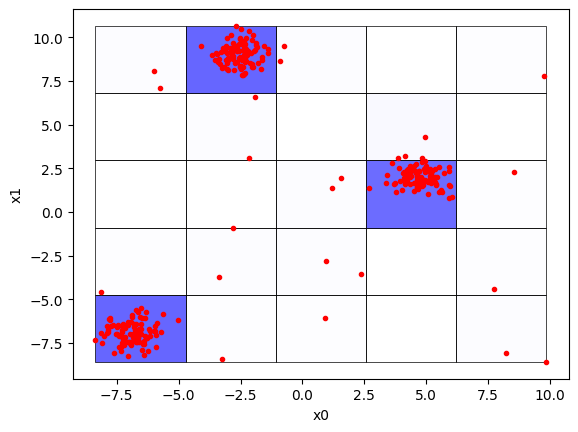

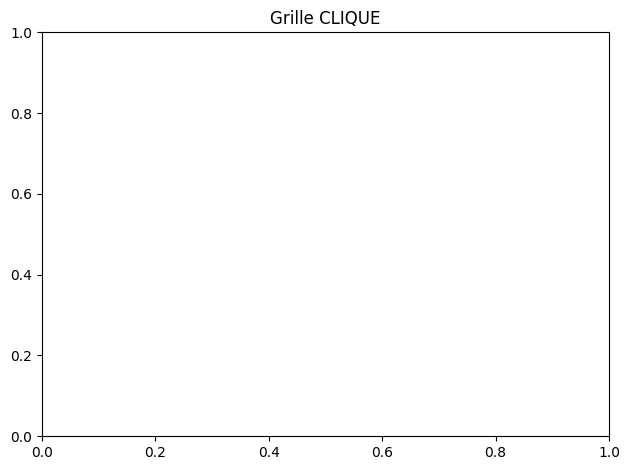

In [12]:

# 2. CLIQUE avec les bons paramètres
clique_instance = clique(data, amount_intervals=5, density_threshold=0)
clique_instance.process()

# 3. Résultats
clusters = clique_instance.get_clusters()
noise = clique_instance.get_noise()

print(f"Clusters trouvés : {len(clusters)}")
print(f"Bruit : {len(noise)} points")

# 4. Visualisation
plt.figure(figsize=(12, 4))

# Graphique 1: Données originales
plt.subplot(1, 3, 1)
plt.scatter(data[:, 0], data[:, 1], c='gray', alpha=0.6)
plt.title("Données Originales")

# Graphique 2: Résultats CLIQUE
plt.subplot(1, 3, 2)
colors = ['red', 'blue', 'green', 'orange', 'purple']

for i, cluster in enumerate(clusters):
    cluster_data = data[cluster]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], 
                c=colors[i % len(colors)], label=f'Cluster {i}', alpha=0.7)

if noise:
    noise_data = data[noise]
    plt.scatter(noise_data[:, 0], noise_data[:, 1], 
                c='black', marker='x', s=50, label='Bruit')

plt.title("Résultats CLIQUE")
plt.legend()

# Graphique 3: Grille
plt.subplot(1, 3, 3)
clique_visualizer.show_grid(clique_instance.get_cells(), data) #show_grid() : fonction spéciale de pyclustering qui affiche la grille utilisée par CLIQUE et montre comment l'espace a été divisé et quelles cellules sont denses
plt.title("Grille CLIQUE")

plt.tight_layout()
plt.show()